# **Install & Imports**

In [1]:
!pip install ultralytics filterpy lap -q

import subprocess, sys
try:
    import lap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lap', '-q'])

import os, cv2, pickle, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
from ultralytics import YOLO
import yaml as pyyaml
from types import SimpleNamespace as _NS

print(' All dependencies loaded.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 All dependencies loaded.


# **Config & Paths**

In [2]:
VIDEO_PATH   = '/kaggle/input/datasets/junaeidali123/bug-03/videoplayback (1).mp4'
MODEL_PATH   = '/kaggle/input/datasets/junaeidali123/output/yolo_runs/agroinsect_v1/weights/best.pt'
TRACKER_SAVE = '/kaggle/input/datasets/junaeidali123/tracker-out/tracker_states'
OUTPUT_BASE  = '/kaggle/working/video_outputs'
os.makedirs(OUTPUT_BASE, exist_ok=True)

CONF_THRESH  = 0.25
IOU_THRESH   = 0.3
MAX_AGE      = 5
MIN_HITS     = 1
TRAIL_LENGTH = 30
FRAME_SIZE   = (640, 480)

LINE_Y       = int(FRAME_SIZE[1] * 0.55)
LINE_X1, LINE_X2 = 20, FRAME_SIZE[0] - 20

PALETTE = [
    (0,255,128), (0,128,255), (255,0,128), (255,128,0),
    (128,0,255), (0,255,255), (255,0,255), (255,255,0),
    (0,200,100), (100,0,200), (200,100,0), (0,100,200),
    (200,0,100), (100,200,0), (50,150,250),(250,150,50),
]

def get_color(track_id):
    return PALETTE[int(track_id) % len(PALETTE)]

print(f' Config set.')
print(f'   Video  : {VIDEO_PATH}')
print(f'   Model  : {MODEL_PATH}')
print(f'   States : {TRACKER_SAVE}')
print(f'   Output : {OUTPUT_BASE}')

 Config set.
   Video  : /kaggle/input/datasets/junaeidali123/bug-03/videoplayback (1).mp4
   Model  : /kaggle/input/datasets/junaeidali123/output/yolo_runs/agroinsect_v1/weights/best.pt
   States : /kaggle/input/datasets/junaeidali123/tracker-out/tracker_states
   Output : /kaggle/working/video_outputs


#  Load Model & Probe Video

In [3]:
model = YOLO(MODEL_PATH)
CLASS_NAMES = model.names
print(f' Model loaded.')
print(f'   Classes: {CLASS_NAMES}')

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f'Cannot open video: {VIDEO_PATH}'
VID_FPS    = cap.get(cv2.CAP_PROP_FPS)
VID_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
VID_W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f'   Video  : {VID_W}×{VID_H}  {VID_FPS:.1f} fps  {VID_FRAMES} frames')

 Model loaded.
   Classes: {0: 'insect_0', 1: 'insect_1', 2: 'insect_2', 3: 'insect_3'}
   Video  : 360×640  30.0 fps  449 frames


# **Reload Saved Tracker States**

In [4]:
import pickle, os, shutil
import numpy as np
import yaml
from collections import defaultdict
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter

# ── IoU helper ────────────────────────────────────────────────
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    interW = max(0, xB - xA); interH = max(0, yB - yA)
    inter  = interW * interH
    areaA  = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB  = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union  = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

# ── SimpleIoUTracker ──────────────────────────────────────────
class SimpleIoUTracker:
    def __init__(self, iou_thresh=0.3, max_age=5):
        self.iou_thresh    = iou_thresh
        self.max_age       = max_age
        self.tracks        = {}
        self.next_id       = 1
        self.track_history = defaultdict(list)

    def update(self, detections):
        if len(detections) == 0:
            to_del = []
            for tid in self.tracks:
                self.tracks[tid]['age'] += 1
                if self.tracks[tid]['age'] > self.max_age:
                    to_del.append(tid)
            for tid in to_del: del self.tracks[tid]
            return []
        track_ids   = list(self.tracks.keys())
        track_boxes = [self.tracks[t]['bbox'] for t in track_ids]
        det_boxes   = detections[:, :4]
        results     = []
        if len(track_ids) == 0:
            for det in detections:
                tid = self.next_id; self.next_id += 1
                self.tracks[tid] = {'bbox': det[:4], 'age': 0, 'hits': 1, 'cls': int(det[5])}
                self.track_history[tid].append(((det[0]+det[2])/2, (det[1]+det[3])/2))
                results.append((tid, *det[:4], int(det[5])))
            return results
        cost = np.zeros((len(track_ids), len(det_boxes)))
        for i, tb in enumerate(track_boxes):
            for j, db in enumerate(det_boxes):
                cost[i, j] = 1 - iou(tb, db)
        row_ind, col_ind = linear_sum_assignment(cost)
        matched_tracks = set(); matched_dets = set()
        for r, c in zip(row_ind, col_ind):
            if cost[r, c] <= (1 - self.iou_thresh):
                tid = track_ids[r]; det = detections[c]
                self.tracks[tid]['bbox'] = det[:4]
                self.tracks[tid]['age']  = 0
                self.tracks[tid]['hits'] += 1
                cx, cy = (det[0]+det[2])/2, (det[1]+det[3])/2
                self.track_history[tid].append((cx, cy))
                if len(self.track_history[tid]) > TRAIL_LENGTH:
                    self.track_history[tid].pop(0)
                results.append((tid, *det[:4], int(det[5])))
                matched_tracks.add(r); matched_dets.add(c)
        for j, det in enumerate(detections):
            if j not in matched_dets:
                tid = self.next_id; self.next_id += 1
                self.tracks[tid] = {'bbox': det[:4], 'age': 0, 'hits': 1, 'cls': int(det[5])}
                self.track_history[tid].append(((det[0]+det[2])/2, (det[1]+det[3])/2))
                results.append((tid, *det[:4], int(det[5])))
        to_del = []
        for i, tid in enumerate(track_ids):
            if i not in matched_tracks:
                self.tracks[tid]['age'] += 1
                if self.tracks[tid]['age'] > self.max_age: to_del.append(tid)
        for tid in to_del: del self.tracks[tid]
        return results

# ── KalmanBoxTracker ──────────────────────────────────────────
class KalmanBoxTracker:
    count = 0
    def __init__(self, bbox, cls):
        KalmanBoxTracker.count += 1
        self.id = KalmanBoxTracker.count; self.cls = cls
        self.age = 0; self.hits = 0; self.hit_streak = 0
        self.time_since_update = 0; self.history = []
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([
            [1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],
            [0,0,0,1,0,0,0],[0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1],
        ], dtype=float)
        self.kf.H = np.array([
            [1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0],
        ], dtype=float)
        self.kf.R[2:,2:] *= 10.; self.kf.P[4:,4:] *= 1000.
        self.kf.P *= 10.; self.kf.Q[-1,-1] *= 0.01; self.kf.Q[4:,4:] *= 0.01
        self.kf.x[:4] = self._bbox_to_z(bbox)

    @staticmethod
    def _bbox_to_z(bbox):
        x1,y1,x2,y2 = bbox; w=x2-x1; h=y2-y1
        return np.array([[x1+w/2],[y1+h/2],[w*h],[w/float(h) if h!=0 else 1]], dtype=float)

    @staticmethod
    def _z_to_bbox(x):
        cx,cy,s,r = x[0],x[1],x[2],x[3]
        w = np.sqrt(abs(s*r)); h = abs(s)/w if w!=0 else 1
        return np.array([cx-w/2, cy-h/2, cx+w/2, cy+h/2])

    def predict(self):
        if self.kf.x[6]+self.kf.x[2] <= 0: self.kf.x[6] = 0
        self.kf.predict(); self.age += 1
        if self.time_since_update > 0: self.hit_streak = 0
        self.time_since_update += 1
        pred = self._z_to_bbox(self.kf.x); self.history.append(pred); return pred

    def update(self, bbox):
        self.time_since_update = 0; self.history = []
        self.hits += 1; self.hit_streak += 1
        self.kf.update(self._bbox_to_z(bbox))

    def get_state(self): return self._z_to_bbox(self.kf.x)


def associate_detections_to_trackers(dets, trks, iou_threshold=0.3):
    if len(trks) == 0:
        return np.empty((0,2),dtype=int), np.arange(len(dets)), np.empty((0,),dtype=int)
    cost = np.zeros((len(dets), len(trks)))
    for d, det in enumerate(dets):
        for t, trk in enumerate(trks): cost[d,t] = 1 - iou(det, trk)
    row_ind, col_ind = linear_sum_assignment(cost)
    matched, unmatched_d, unmatched_t = [], [], []
    for d in range(len(dets)):
        if d not in row_ind: unmatched_d.append(d)
    for t in range(len(trks)):
        if t not in col_ind: unmatched_t.append(t)
    for r, c in zip(row_ind, col_ind):
        if cost[r,c] > 1 - iou_threshold:
            unmatched_d.append(r); unmatched_t.append(c)
        else:
            matched.append([r,c])
    return np.array(matched), np.array(unmatched_d), np.array(unmatched_t)


class SORTTracker:
    def __init__(self, max_age=5, min_hits=1, iou_threshold=0.3):
        self.max_age = max_age; self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []; self.frame_count = 0
        self.track_history = defaultdict(list)
        KalmanBoxTracker.count = 0

    def update(self, detections):
        self.frame_count += 1
        det_boxes = detections[:,:4] if len(detections) else np.empty((0,4))
        trks = np.array([t.predict() for t in self.trackers])
        if len(trks) == 0: trks = np.empty((0,4))
        matched, unmatched_d, unmatched_t = associate_detections_to_trackers(
            det_boxes, trks, self.iou_threshold)
        cls_map = {i: int(detections[i,5]) for i in range(len(detections))}
        for m in matched: self.trackers[m[1]].update(det_boxes[m[0]])
        for i in unmatched_d:
            self.trackers.append(KalmanBoxTracker(det_boxes[i], cls_map.get(i, 0)))
        results = []; survivors = []
        for t in self.trackers:
            if t.time_since_update <= self.max_age:
                survivors.append(t)
                if t.time_since_update == 0 and \
                   (t.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
                    bbox = t.get_state()
                    cx, cy = (bbox[0]+bbox[2])/2, (bbox[1]+bbox[3])/2
                    self.track_history[t.id].append((cx, cy))
                    if len(self.track_history[t.id]) > TRAIL_LENGTH:
                        self.track_history[t.id].pop(0)
                    results.append((t.id, *bbox, t.cls))
        self.trackers = survivors
        return results

# ── Copy tracker states to writable dir ──────────────────────
WRITABLE_TRACKER_SAVE = '/kaggle/working/tracker_states'
os.makedirs(WRITABLE_TRACKER_SAVE, exist_ok=True)
for fname in os.listdir(TRACKER_SAVE):
    shutil.copy(os.path.join(TRACKER_SAVE, fname), os.path.join(WRITABLE_TRACKER_SAVE, fname))

# ── Reload saved .pkl states ──────────────────────────────────
with open(f'{TRACKER_SAVE}/simpleiou_state.pkl', 'rb') as f:
    loaded_simple = pickle.load(f)

tracker1 = SimpleIoUTracker(
    iou_thresh=loaded_simple['iou_thresh'],
    max_age=loaded_simple['max_age'])
tracker1.tracks        = loaded_simple['tracks']
tracker1.next_id       = loaded_simple['next_id']
tracker1.track_history = defaultdict(list, loaded_simple['track_history'])

with open(f'{TRACKER_SAVE}/sort_state.pkl', 'rb') as f:
    loaded_sort = pickle.load(f)

tracker2 = SORTTracker(max_age=MAX_AGE, min_hits=MIN_HITS, iou_threshold=IOU_THRESH)
tracker2.frame_count   = loaded_sort['frame_count']
tracker2.track_history = defaultdict(list, loaded_sort['track_history'])
KalmanBoxTracker.count = loaded_sort['total_ids']
for lt in loaded_sort['live_trackers']:
    kt = KalmanBoxTracker.__new__(KalmanBoxTracker)
    kt.id=lt['id']; kt.cls=lt['cls']; kt.hits=lt['hits']; kt.age=lt['age']
    kt.hit_streak=lt['hit_streak']; kt.time_since_update=lt['time_since_update']
    kt.history=[]
    kt.kf = KalmanFilter(dim_x=7, dim_z=4)
    kt.kf.x=np.array(lt['kf_x']); kt.kf.P=np.array(lt['kf_P'])
    kt.kf.F=np.array(lt['kf_F']); kt.kf.H=np.array(lt['kf_H'])
    kt.kf.R=np.array(lt['kf_R']); kt.kf.Q=np.array(lt['kf_Q'])
    tracker2.trackers.append(kt)

with open(f'{TRACKER_SAVE}/bytetrack_state.pkl', 'rb') as f:
    loaded_byte = pickle.load(f)
with open(f'{TRACKER_SAVE}/botsort_state.pkl', 'rb') as f:
    loaded_bot  = pickle.load(f)

bytetrack_cfg_path = f'{WRITABLE_TRACKER_SAVE}/bytetrack.yaml'
botsort_cfg_path   = f'{WRITABLE_TRACKER_SAVE}/botsort.yaml'

# Patch thresholds to match CONF_THRESH
for cfg_path in [bytetrack_cfg_path, botsort_cfg_path]:
    with open(cfg_path) as f: cfg = pyyaml.safe_load(f)
    cfg['track_high_thresh'] = CONF_THRESH
    cfg['new_track_thresh']  = CONF_THRESH
    cfg['track_low_thresh']  = max(0.1, CONF_THRESH * 0.5)
    with open(cfg_path, 'w') as f: pyyaml.dump(cfg, f)

print(' All tracker states reloaded.')
print(f'   SimpleIoU next_id    : {tracker1.next_id}')
print(f'   SORT frame_count     : {tracker2.frame_count}  live: {len(tracker2.trackers)}')
print(f'   ByteTrack max_id     : {loaded_byte["max_track_id"]}')
print(f'   BoT-SORT  max_id     : {loaded_bot["max_track_id"]}')

 All tracker states reloaded.
   SimpleIoU next_id    : 6
   SORT frame_count     : 10  live: 2
   ByteTrack max_id     : 1
   BoT-SORT  max_id     : 6


# **Full Overlay Draw Function**

In [5]:
def draw_full_overlay(frame, active_tracks, track_history,
                       class_names, line_y,
                       crossed_ids, cross_counts,
                       tracker_name='', frame_idx=0):
    canvas = frame.copy()
    h, w   = canvas.shape[:2]
    font   = cv2.FONT_HERSHEY_SIMPLEX

    # 1. Motion trails
    for tid, x1, y1, x2, y2, cls in active_tracks:
        trail = list(track_history.get(tid, []))
        color = get_color(tid)
        for k in range(1, len(trail)):
            alpha = k / max(len(trail), 1)
            pt1   = (int(trail[k-1][0]), int(trail[k-1][1]))
            pt2   = (int(trail[k][0]),   int(trail[k][1]))
            thick = max(1, int(3 * alpha))
            tcol  = tuple(int(c * alpha) for c in color)
            cv2.line(canvas, pt1, pt2, tcol, thick, cv2.LINE_AA)
            cv2.circle(canvas, pt2, max(1, int(4*alpha)), tcol, -1)

    # 2. Bounding boxes + ID/class labels
    for tid, x1, y1, x2, y2, cls in active_tracks:
        color = get_color(tid)
        x1i,y1i,x2i,y2i = int(x1),int(y1),int(x2),int(y2)
        cv2.rectangle(canvas, (x1i,y1i), (x2i,y2i), color, 2)
        label = f'ID{tid} {class_names.get(cls, str(cls))}'
        (tw,th), _ = cv2.getTextSize(label, font, 0.45, 1)
        ty = max(y1i - 4, th + 4)
        cv2.rectangle(canvas, (x1i, ty-th-4), (x1i+tw+4, ty+2), color, -1)
        cv2.putText(canvas, label, (x1i+2, ty-2), font, 0.45, (0,0,0), 1, cv2.LINE_AA)

    # 3. Direction arrows
    for tid, x1, y1, x2, y2, cls in active_tracks:
        trail = list(track_history.get(tid, []))
        if len(trail) >= 2:
            color = get_color(tid)
            p1 = (int(trail[-2][0]), int(trail[-2][1]))
            p2 = (int(trail[-1][0]), int(trail[-1][1]))
            dx, dy = p2[0]-p1[0], p2[1]-p1[1]
            dist   = (dx**2 + dy**2) ** 0.5
            if dist > 2:
                scale = 12 / dist
                tip   = (int(p2[0]+dx*scale), int(p2[1]+dy*scale))
                cv2.arrowedLine(canvas, p1, tip, color, 2, cv2.LINE_AA, tipLength=0.45)

    # 4. Counting-line crossing detection
    for tid, x1, y1, x2, y2, cls in active_tracks:
        trail = list(track_history.get(tid, []))
        if len(trail) >= 2 and tid not in crossed_ids:
            prev_y = trail[-2][1]
            curr_y = trail[-1][1]
            if prev_y < line_y <= curr_y:
                crossed_ids.add(tid); cross_counts['down'] += 1
            elif prev_y > line_y >= curr_y:
                crossed_ids.add(tid); cross_counts['up']   += 1

    # 5. Counting line
    cv2.line(canvas, (LINE_X1, line_y), (LINE_X2, line_y), (0,255,255), 2, cv2.LINE_AA)
    cv2.putText(canvas, f'IN:{cross_counts["down"]}  OUT:{cross_counts["up"]}',
                (LINE_X1+4, line_y-6), font, 0.5, (0,255,255), 1, cv2.LINE_AA)

    # 6. HUD panel
    cls_counts = defaultdict(int)
    for tid,x1,y1,x2,y2,cls in active_tracks: cls_counts[cls] += 1
    panel_lines = [
        (f'Tracker : {tracker_name}',  (180,180,180)),
        (f'Frame   : {frame_idx}',     (180,180,180)),
        (f'Active  : {len(active_tracks)}', (100,255,100)),
        (f'Total   : {cross_counts["down"]+cross_counts["up"]}', (100,200,255)),
    ]
    for cls_id, cnt in sorted(cls_counts.items()):
        panel_lines.append((f'  {class_names.get(cls_id,str(cls_id))}: {cnt}', (200,220,255)))

    pad, lh     = 6, 18
    panel_h     = len(panel_lines) * lh + pad * 2
    overlay     = canvas.copy()
    cv2.rectangle(overlay, (4,4), (194, 4+panel_h), (20,20,20), -1)
    cv2.addWeighted(overlay, 0.55, canvas, 0.45, 0, canvas)
    for i, (text, color) in enumerate(panel_lines):
        cv2.putText(canvas, text, (8, pad + lh*(i+1)), font, 0.42, color, 1, cv2.LINE_AA)

    return canvas

print(' draw_full_overlay() defined.')

 draw_full_overlay() defined.


# **Generic Video-Processing Loop + SimpleIoU**

In [6]:
def run_tracker_on_video(tracker_name, tracker_update_fn, track_history_fn,
                          video_path, output_path, model,
                          conf_thresh, frame_size, line_y):
    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

    all_results  = []
    crossed_ids  = set()
    cross_counts = {'up': 0, 'down': 0}
    heatmap_acc  = np.zeros((frame_size[1], frame_size[0]), dtype=np.float32)
    frame_idx    = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(frame, frame_size)

        det_res = model(frame, conf=conf_thresh, verbose=False)[0]
        boxes   = det_res.boxes.xyxy.cpu().numpy()  if len(det_res.boxes) else np.empty((0,4))
        confs   = det_res.boxes.conf.cpu().numpy()  if len(det_res.boxes) else np.empty((0,))
        clss    = det_res.boxes.cls.cpu().numpy()   if len(det_res.boxes) else np.empty((0,))
        dets    = np.concatenate([boxes, confs[:,None], clss[:,None]], axis=1) \
                  if len(boxes) else np.empty((0,6))

        active = tracker_update_fn(dets)
        all_results.append(active)

        for tid, x1, y1, x2, y2, cls in active:
            cx, cy = int((x1+x2)/2), int((y1+y2)/2)
            bw, bh = int(x2-x1), int(y2-y1)
            xl=max(0,cx-bw//2); xr=min(frame_size[0],cx+bw//2)
            yl=max(0,cy-bh//2); yr=min(frame_size[1],cy+bh//2)
            heatmap_acc[yl:yr, xl:xr] += 1.0

        annotated = draw_full_overlay(
            frame, active, track_history_fn(),
            CLASS_NAMES, line_y, crossed_ids, cross_counts,
            tracker_name, frame_idx)
        out.write(annotated)
        frame_idx += 1
        if frame_idx % 100 == 0:
            print(f'  [{tracker_name}] frame {frame_idx}  active={len(active)}')

    cap.release(); out.release()
    print(f' [{tracker_name}] done — {frame_idx} frames → {output_path}')
    print(f'   Crossed ↓{cross_counts["down"]}  ↑{cross_counts["up"]}')
    return all_results, cross_counts, heatmap_acc


# ── Run SimpleIoU ─────────────────────────────────────────────
tracker1_vid = SimpleIoUTracker(iou_thresh=IOU_THRESH, max_age=MAX_AGE)
tracker1_vid.next_id = tracker1.next_id  # continue IDs from saved state

siou_results, siou_crosses, siou_heatmap = run_tracker_on_video(
    tracker_name      = 'SimpleIoU',
    tracker_update_fn = tracker1_vid.update,
    track_history_fn  = lambda: tracker1_vid.track_history,
    video_path        = VIDEO_PATH,
    output_path       = f'{OUTPUT_BASE}/simpleiou_output.mp4',
    model             = model,
    conf_thresh       = CONF_THRESH,
    frame_size        = FRAME_SIZE,
    line_y            = LINE_Y,
)

  [SimpleIoU] frame 100  active=0
  [SimpleIoU] frame 200  active=1
  [SimpleIoU] frame 300  active=1
  [SimpleIoU] frame 400  active=1
 [SimpleIoU] done — 449 frames → /kaggle/working/video_outputs/simpleiou_output.mp4
   Crossed ↓0  ↑0


# **SORT on Video**

In [7]:
tracker2_vid = SORTTracker(max_age=MAX_AGE, min_hits=MIN_HITS, iou_threshold=IOU_THRESH)
tracker2_vid.frame_count   = tracker2.frame_count
tracker2_vid.track_history = defaultdict(list, tracker2.track_history)
tracker2_vid.trackers      = tracker2.trackers
KalmanBoxTracker.count     = loaded_sort['total_ids']

sort_results, sort_crosses, sort_heatmap = run_tracker_on_video(
    tracker_name      = 'SORT',
    tracker_update_fn = tracker2_vid.update,
    track_history_fn  = lambda: tracker2_vid.track_history,
    video_path        = VIDEO_PATH,
    output_path       = f'{OUTPUT_BASE}/sort_output.mp4',
    model             = model,
    conf_thresh       = CONF_THRESH,
    frame_size        = FRAME_SIZE,
    line_y            = LINE_Y,
)

/tmp/ipykernel_24/3331317247.py:131: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for t, trk in enumerate(trks): cost[d,t] = 1 - iou(det, trk)
/tmp/ipykernel_24/1330224102.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cx, cy = int((x1+x2)/2), int((y1+y2)/2)
/tmp/ipykernel_24/1330224102.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bw, bh = int(x2-x1), int(y2-y1)
/tmp/ipykernel_24/2717508684.py:25: DeprecationWarning: Conversion of an array with ndim 

  [SORT] frame 100  active=0
  [SORT] frame 200  active=1
  [SORT] frame 300  active=1
  [SORT] frame 400  active=1
 [SORT] done — 449 frames → /kaggle/working/video_outputs/sort_output.mp4
   Crossed ↓0  ↑0


# **ByteTrack on Video**

In [8]:
model_byte = YOLO(MODEL_PATH)   # fresh model — required for persist=True

byte_history     = defaultdict(list)
byte_crossed_ids = set()
byte_crosses     = {'up': 0, 'down': 0}
byte_heatmap     = np.zeros((FRAME_SIZE[1], FRAME_SIZE[0]), dtype=np.float32)
byte_results     = []
byte_max_id      = loaded_byte['max_track_id']

cap    = cv2.VideoCapture(VIDEO_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS) or 25
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(f'{OUTPUT_BASE}/bytetrack_output.mp4', fourcc, fps, FRAME_SIZE)
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.resize(frame, FRAME_SIZE)

    res = model_byte.track(frame, conf=CONF_THRESH,
                           tracker=bytetrack_cfg_path,
                           persist=True, verbose=False)[0]
    active = []
    if res.boxes.id is not None:
        for box, tid, cls in zip(res.boxes.xyxy, res.boxes.id, res.boxes.cls):
            x1,y1,x2,y2 = box.cpu().numpy()
            tid = int(tid.cpu()); cls = int(cls.cpu())
            byte_max_id = max(byte_max_id, tid)
            cx, cy = (x1+x2)/2, (y1+y2)/2
            byte_history[tid].append((cx, cy))
            if len(byte_history[tid]) > TRAIL_LENGTH: byte_history[tid].pop(0)
            active.append((tid, x1, y1, x2, y2, cls))
            bw,bh = int(x2-x1), int(y2-y1)
            xl=max(0,int(cx)-bw//2); xr=min(FRAME_SIZE[0],int(cx)+bw//2)
            yl=max(0,int(cy)-bh//2); yr=min(FRAME_SIZE[1],int(cy)+bh//2)
            byte_heatmap[yl:yr, xl:xr] += 1.0

    byte_results.append(active)
    annotated = draw_full_overlay(frame, active, byte_history,
                                   CLASS_NAMES, LINE_Y,
                                   byte_crossed_ids, byte_crosses,
                                   'ByteTrack', frame_idx)
    out.write(annotated)
    frame_idx += 1
    if frame_idx % 100 == 0:
        print(f'  [ByteTrack] frame {frame_idx}  active={len(active)}')

cap.release(); out.release()
print(f' [ByteTrack] done — {frame_idx} frames → {OUTPUT_BASE}/bytetrack_output.mp4')
print(f'   Crossed ↓{byte_crosses["down"]}  ↑{byte_crosses["up"]}')

  [ByteTrack] frame 100  active=0
  [ByteTrack] frame 200  active=1
  [ByteTrack] frame 300  active=1
  [ByteTrack] frame 400  active=1
 [ByteTrack] done — 449 frames → /kaggle/working/video_outputs/bytetrack_output.mp4
   Crossed ↓0  ↑0


#  BoT-SORT on Video

In [9]:
model_bot = YOLO(MODEL_PATH)   # fresh model — required for persist=True

bot_history     = defaultdict(list)
bot_crossed_ids = set()
bot_crosses     = {'up': 0, 'down': 0}
bot_heatmap     = np.zeros((FRAME_SIZE[1], FRAME_SIZE[0]), dtype=np.float32)
bot_results     = []
bot_max_id      = loaded_bot['max_track_id']

cap    = cv2.VideoCapture(VIDEO_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS) or 25
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(f'{OUTPUT_BASE}/botsort_output.mp4', fourcc, fps, FRAME_SIZE)
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.resize(frame, FRAME_SIZE)

    res = model_bot.track(frame, conf=CONF_THRESH,
                          tracker=botsort_cfg_path,
                          persist=True, verbose=False)[0]
    active = []
    if res.boxes is not None and res.boxes.id is not None:
        boxes = res.boxes.xyxy.cpu().numpy()
        ids   = res.boxes.id.cpu().numpy().astype(int)
        clss  = res.boxes.cls.cpu().numpy().astype(int)
        for box, tid, cls in zip(boxes, ids, clss):
            x1,y1,x2,y2 = box
            bot_max_id = max(bot_max_id, tid)
            cx, cy = (x1+x2)/2, (y1+y2)/2
            bot_history[tid].append((cx, cy))
            if len(bot_history[tid]) > TRAIL_LENGTH: bot_history[tid].pop(0)
            active.append((tid, x1, y1, x2, y2, cls))
            bw,bh = int(x2-x1), int(y2-y1)
            xl=max(0,int(cx)-bw//2); xr=min(FRAME_SIZE[0],int(cx)+bw//2)
            yl=max(0,int(cy)-bh//2); yr=min(FRAME_SIZE[1],int(cy)+bh//2)
            bot_heatmap[yl:yr, xl:xr] += 1.0

    bot_results.append(active)
    annotated = draw_full_overlay(frame, active, bot_history,
                                   CLASS_NAMES, LINE_Y,
                                   bot_crossed_ids, bot_crosses,
                                   'BoT-SORT', frame_idx)
    out.write(annotated)
    frame_idx += 1
    if frame_idx % 100 == 0:
        print(f'  [BoT-SORT] frame {frame_idx}  active={len(active)}')

cap.release(); out.release()
print(f' [BoT-SORT] done — {frame_idx} frames → {OUTPUT_BASE}/botsort_output.mp4')
print(f'   Crossed ↓{bot_crosses["down"]}  ↑{bot_crosses["up"]}')

  [BoT-SORT] frame 100  active=0
  [BoT-SORT] frame 200  active=1
  [BoT-SORT] frame 300  active=1
  [BoT-SORT] frame 400  active=1
 [BoT-SORT] done — 449 frames → /kaggle/working/video_outputs/botsort_output.mp4
   Crossed ↓0  ↑0


# **Heatmaps**

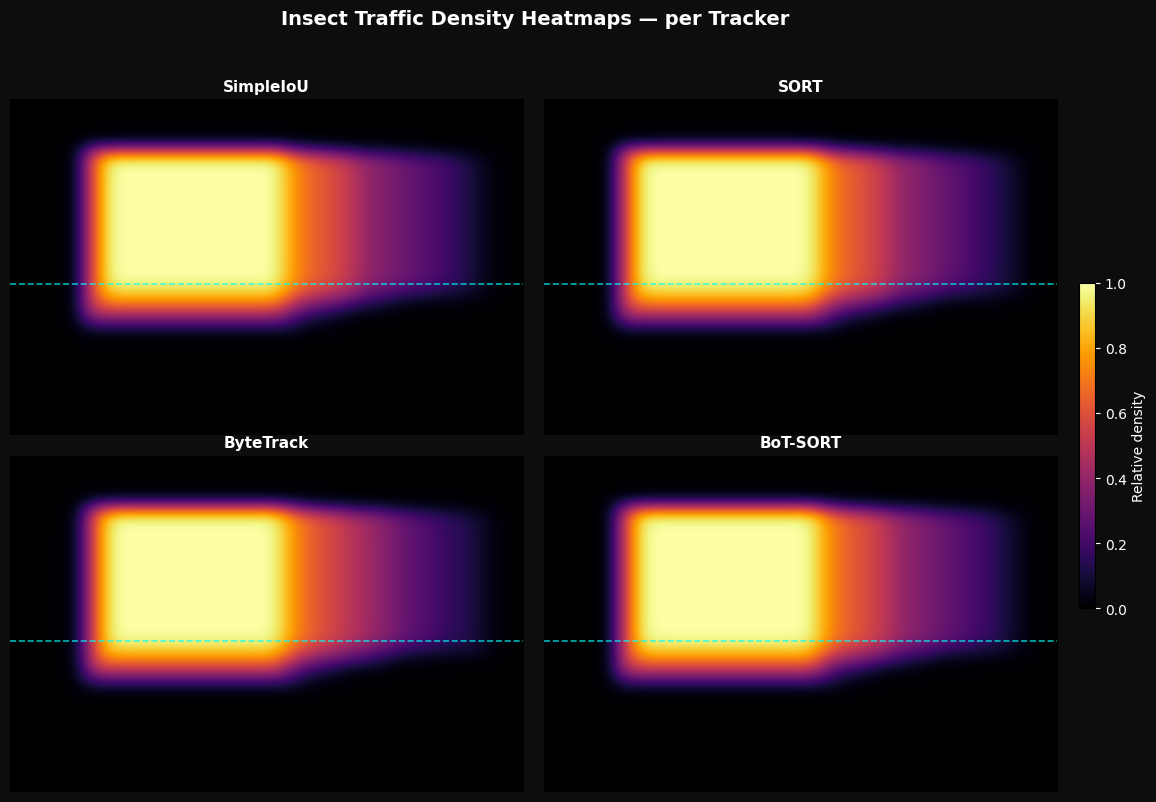

 Per-tracker heatmap → /kaggle/working/video_outputs/heatmap_per_tracker.png


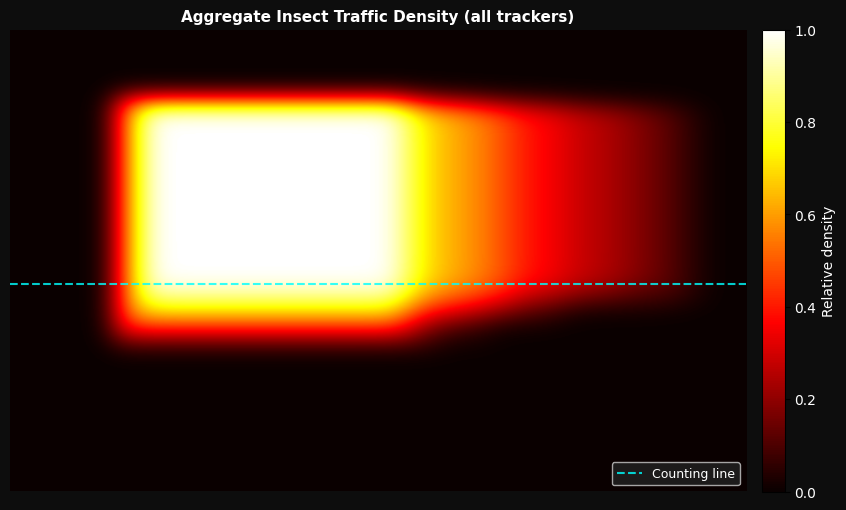

 Fused heatmap → /kaggle/working/video_outputs/heatmap_fused.png


In [10]:
from scipy.ndimage import gaussian_filter

def render_heatmap(acc, title, ax, cmap='inferno'):
    blurred = gaussian_filter(acc, sigma=12)
    if blurred.max() > 0:
        blurred = blurred / blurred.max()
    im = ax.imshow(blurred, cmap=cmap, aspect='auto', interpolation='bilinear')
    ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=6)
    ax.axis('off')
    return im

trackers_heat = [
    ('SimpleIoU', siou_heatmap),
    ('SORT',      sort_heatmap),
    ('ByteTrack', byte_heatmap),
    ('BoT-SORT',  bot_heatmap),
]

# ── 2×2 per-tracker panel ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='#0d0d0d',
                          gridspec_kw={'hspace': 0.06, 'wspace': 0.04})
fig.suptitle('Insect Traffic Density Heatmaps — per Tracker',
             fontsize=14, fontweight='bold', color='white', y=0.98)
for ax, (name, hmap) in zip(axes.flat, trackers_heat):
    ax.set_facecolor('#0d0d0d')
    im = render_heatmap(hmap, name, ax)
    ax.axhline(y=LINE_Y, color='cyan', linewidth=1.2, linestyle='--', alpha=0.7)

cbar = plt.colorbar(im, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Relative density', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

heat_panel_path = f'{OUTPUT_BASE}/heatmap_per_tracker.png'
plt.savefig(heat_panel_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f' Per-tracker heatmap → {heat_panel_path}')

# ── Fused aggregate ───────────────────────────────────────────
fused = sum(h for _, h in trackers_heat)

fig2, ax2 = plt.subplots(figsize=(10, 6), facecolor='#0d0d0d')
ax2.set_facecolor('#0d0d0d')
im2 = render_heatmap(fused, 'Aggregate Insect Traffic Density (all trackers)', ax2, cmap='hot')
ax2.axhline(y=LINE_Y, color='cyan', linewidth=1.5, linestyle='--', alpha=0.8, label='Counting line')
ax2.legend(loc='lower right', fontsize=9, facecolor='#222', labelcolor='white')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.03, pad=0.02)
cbar2.set_label('Relative density', color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

fused_path = f'{OUTPUT_BASE}/heatmap_fused.png'
plt.savefig(fused_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f' Fused heatmap → {fused_path}')

# Summary

In [11]:
import pandas as pd

def count_unique_ids(results):
    ids = set()
    for frame in results:
        for item in frame: ids.add(item[0])
    return len(ids)

def avg_per_frame(results):
    if not results: return 0
    return round(sum(len(f) for f in results) / len(results), 2)

summary_data = [
    {'Tracker':'SimpleIoU', 'Unique IDs':count_unique_ids(siou_results),
     'Avg/frame':avg_per_frame(siou_results),
     'Crossed ↓':siou_crosses['down'], 'Crossed ↑':siou_crosses['up'],
     'Output':'simpleiou_output.mp4'},
    {'Tracker':'SORT',      'Unique IDs':count_unique_ids(sort_results),
     'Avg/frame':avg_per_frame(sort_results),
     'Crossed ↓':sort_crosses['down'], 'Crossed ↑':sort_crosses['up'],
     'Output':'sort_output.mp4'},
    {'Tracker':'ByteTrack', 'Unique IDs':count_unique_ids(byte_results),
     'Avg/frame':avg_per_frame(byte_results),
     'Crossed ↓':byte_crosses['down'], 'Crossed ↑':byte_crosses['up'],
     'Output':'bytetrack_output.mp4'},
    {'Tracker':'BoT-SORT',  'Unique IDs':count_unique_ids(bot_results),
     'Avg/frame':avg_per_frame(bot_results),
     'Crossed ↓':bot_crosses['down'],  'Crossed ↑':bot_crosses['up'],
     'Output':'botsort_output.mp4'},
]

df = pd.DataFrame(summary_data)
print('\n Tracker Comparison Summary')
print('=' * 72)
print(df.to_string(index=False))
print('=' * 72)

with open(f'{OUTPUT_BASE}/tracker_video_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print(f'\n Summary JSON → {OUTPUT_BASE}/tracker_video_summary.json')
print('\n Output files:')
for p in sorted(Path(OUTPUT_BASE).glob('*')):
    print(f'   {p.name:45s}  {p.stat().st_size/1024/1024:.1f} MB')


 Tracker Comparison Summary
  Tracker  Unique IDs  Avg/frame  Crossed ↓  Crossed ↑               Output
SimpleIoU           5       0.91          0          0 simpleiou_output.mp4
     SORT           4       0.90          0          0      sort_output.mp4
ByteTrack           3       0.88          0          0 bytetrack_output.mp4
 BoT-SORT           3       0.88          0          0   botsort_output.mp4

 Summary JSON → /kaggle/working/video_outputs/tracker_video_summary.json

 Output files:
   botsort_output.mp4                             2.6 MB
   bytetrack_output.mp4                           2.6 MB
   heatmap_fused.png                              0.1 MB
   heatmap_per_tracker.png                        0.2 MB
   simpleiou_output.mp4                           2.9 MB
   sort_output.mp4                                2.7 MB
   tracker_video_summary.json                     0.0 MB


# **SimpleIOU Output Video**

In [12]:
import subprocess, base64, os
from IPython.display import HTML

def encode_and_play(input_path, output_path):
    # Re-encode with libx264
    subprocess.run([
        'ffmpeg', '-y',
        '-i', input_path,
        '-vcodec', 'libx264',
        '-pix_fmt', 'yuv420p',
        '-crf', '23',
        output_path
    ], capture_output=True)

    # Check file size
    size = os.path.getsize(output_path)
    print(f"File size: {size} bytes ({size / (1024*1024):.2f} MB)")

    # Play
    with open(output_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()

    return HTML(f'<video width="800" controls><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

encode_and_play(
    '/kaggle/working/video_outputs/simpleiou_output.mp4',
    '/kaggle/working/video_outputs/simpleiou_x264.mp4'
)

File size: 660882 bytes (0.63 MB)


# **Sort Output Video**

In [13]:
import subprocess, base64
from IPython.display import HTML

# Re-encode
subprocess.run([
    'ffmpeg', '-y',
    '-i', '/kaggle/working/video_outputs/sort_output.mp4',
    '-vcodec', 'libx264',
    '-pix_fmt', 'yuv420p',
    '-crf', '23',
    '/kaggle/working/video_outputs/sort_x264.mp4'
], capture_output=True)

# Check file exists and size
import os
size = os.path.getsize('/kaggle/working/video_outputs/sort_x264.mp4')
print(f"File size: {size} bytes")

# Play
with open('/kaggle/working/video_outputs/sort_x264.mp4', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

HTML(f'<video width="800" controls><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

File size: 632443 bytes


# **Byte Track OutPut Video**

In [14]:
import subprocess, base64, os
from IPython.display import HTML

subprocess.run([
    'ffmpeg', '-y',
    '-i', '/kaggle/working/video_outputs/bytetrack_output.mp4',
    '-vcodec', 'libx264',
    '-pix_fmt', 'yuv420p',
    '-crf', '23',
    '/kaggle/working/video_outputs/bytetrack_x264.mp4'
], capture_output=True)

with open('/kaggle/working/video_outputs/bytetrack_x264.mp4', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

HTML(f'<video width="800" controls><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

# **Bot-Sort Output Video**

In [15]:
import subprocess, base64, os
from IPython.display import HTML

subprocess.run([
    'ffmpeg', '-y',
    '-i', '/kaggle/working/video_outputs/botsort_output.mp4',
    '-vcodec', 'libx264',
    '-pix_fmt', 'yuv420p',
    '-crf', '23',
    '/kaggle/working/video_outputs/botsort_x264.mp4'
], capture_output=True)

with open('/kaggle/working/video_outputs/botsort_x264.mp4', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

HTML(f'<video width="800" controls><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')